# NTB-07: SHAP Explainability

## Objective
Explain **why** the champion model (tuned LightGBM) makes its predictions using SHAP (SHapley Additive exPlanations).

## Why SHAP?

Tree feature importance (NTB-04) tells us which features are *used*. SHAP tells us:
- **How much** each feature pushes a prediction toward or away from churn
- **Which direction** (higher value = more or less churn risk?)
- **For a specific individual customer** — not just global averages

This is what "explainable AI" means in practice. In telecom, insurance, and banking, you often can't act on a black-box prediction. A retention agent needs to know *why* a customer is at risk.

## Four Visualizations We'll Produce

| Plot | What it shows | Audience |
|---|---|---|
| **Summary (beeswarm)** | Global feature importance + direction + distribution | Data scientist, stakeholder |
| **Bar importance** | Clean top-N feature importance for slides/README | Manager, recruiter |
| **Dependence plot** | How one feature's value changes churn risk | Analyst |
| **Waterfall (local)** | Why *this specific customer* is predicted to churn | Retention agent, regulator |

The waterfall plot is the standout. Being able to say "Customer #4521 has high churn risk because: fiber optic (+0.18), month-to-month contract (+0.15), new customer (+0.12)..." is the difference between a model and a product.

## Output
- 4 high-quality SHAP figures in `reports/figures/`
- SHAP values saved as parquet for reuse
- Comparison of SHAP importances vs LR coefficients (NTB-03)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

import shap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Paths
BASE_DIR = Path(os.getcwd()).parent
PROC_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
FIG_DIR = BASE_DIR / "reports" / "figures"
REPORTS_DIR = BASE_DIR / "reports"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


In [2]:
# Load champion model and data
champion = joblib.load(MODELS_DIR / "champion.joblib")

with open(REPORTS_DIR / "ntb06_champion.json") as f:
    champ_meta = json.load(f)

print(f"Champion: {champ_meta['champion_model']}")
print(f"Champion AUC: {champ_meta['champion_auc_roc']}")

# Load test set (for SHAP computation)
X_test  = pd.read_parquet(PROC_DIR / "X_test.parquet")
y_test  = pd.read_parquet(PROC_DIR / "y_test.parquet")['churn']
X_train = pd.read_parquet(PROC_DIR / "X_train.parquet")

with open(PROC_DIR / "feature_metadata.json") as f:
    metadata = json.load(f)

feature_names = metadata['output_feature_names']
print(f"\nX_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")

Champion: LightGBM (tuned)
Champion AUC: 0.8492

X_test: (1409, 41)
Features: 41


## 2. Build the SHAP Explainer

**`shap.TreeExplainer`** is optimized for tree-based models (Random Forest, XGBoost, LightGBM). It computes exact Shapley values in O(TLD²) time using the tree structure directly — much faster than the model-agnostic `KernelExplainer`.

We compute SHAP values on the **test set** (the 1409 held-out customers). This gives us explainability on data the model has never seen — the most honest evaluation.

In [3]:
# Build SHAP TreeExplainer
explainer = shap.TreeExplainer(champion)

# Compute SHAP values for the full test set
# For binary classification, shap_values is a list [class_0, class_1]
# We want class_1 (churn probability SHAP values)
print("Computing SHAP values on test set...")
shap_values_raw = explainer.shap_values(X_test)

# LightGBM TreeExplainer returns array of shape (n_samples, n_features) for binary
# Handle both list-output and single-array output
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]   # class 1 = churn
else:
    shap_values = shap_values_raw       # already the positive class

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected: ({X_test.shape[0]}, {X_test.shape[1]})")

# Base value (average model output before SHAP adjustments)
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]
print(f"Base value (avg log-odds): {expected_value:.4f}")

Computing SHAP values on test set...
SHAP values shape: (1409, 41)
Expected: (1409, 41)
Base value (avg log-odds): -0.6686


In [4]:
# Sanity check: SHAP values sum to prediction - base_value
# For a single sample, sum(shap_i) + base_value ≈ model output
sample_idx = 0
shap_sum = shap_values[sample_idx].sum() + expected_value
model_output = champion.predict_proba(X_test.iloc[[sample_idx]])[:, 1][0]

# SHAP values are in log-odds space for LightGBM; convert for comparison
import scipy.special
model_logodds = np.log(model_output / (1 - model_output))

print(f"Sample 0 verification:")
print(f"  SHAP sum + base_value = {shap_sum:.4f}")
print(f"  Model log-odds output = {model_logodds:.4f}")
print(f"  Match: {abs(shap_sum - model_logodds) < 0.01}")

Sample 0 verification:
  SHAP sum + base_value = -2.3648
  Model log-odds output = -2.3648
  Match: True


## 3. Global Summary — Beeswarm Plot

The beeswarm is the **most information-dense SHAP plot**. Each dot is one customer. Position on x-axis = SHAP value (impact on churn prediction). Color = feature value (red = high, blue = low).

**Reading example:** If `contract_type_Two year` has dots far to the LEFT (negative SHAP) that are RED — that means "when contract_type_Two year = 1 (i.e., customer IS on two-year contract), churn probability drops sharply." That's exactly what we'd expect.

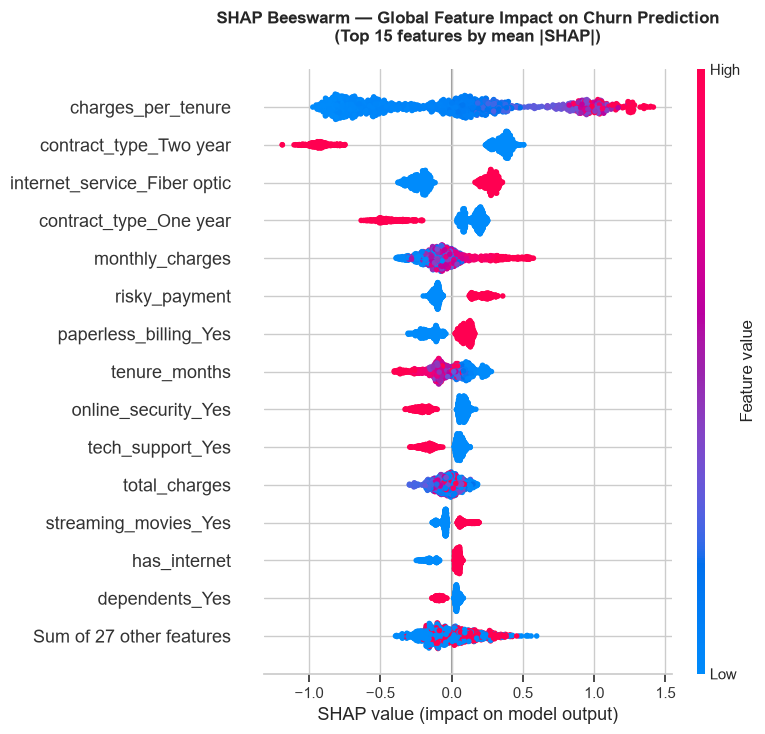

Saved → NTB07_shap_beeswarm.png


In [5]:
# Create SHAP Explanation object for plotting
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_test), expected_value),
    data=X_test.values,
    feature_names=feature_names
)

fig, ax = plt.subplots(figsize=(11, 9))
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("SHAP Beeswarm — Global Feature Impact on Churn Prediction\n(Top 15 features by mean |SHAP|)",
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB07_shap_beeswarm.png")
plt.show()
print(f"Saved → NTB07_shap_beeswarm.png")

**How to read this for your README:**

- **Features at the top** have the most impact on churn predictions
- **Red dots to the right** = high feature value increases churn probability
- **Blue dots to the left** = low feature value decreases churn probability

Cross-check with NTB-03's LR coefficients: the top features should largely agree. If they do — **multi-model consensus** on what drives churn. That's a strong statement for a README or an interview.

## 4. Mean |SHAP| Bar Chart — Clean for README/Slides

The beeswarm is rich but busy. For a README or a slide deck, a simple bar chart of mean absolute SHAP values is cleaner and more readable.

In [6]:
# Compute mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("Top 15 features by mean |SHAP|:")
print(shap_importance_df.head(15).to_string(index=False))

# Save for cross-comparison
shap_importance_df.to_csv(REPORTS_DIR / "ntb07_shap_importance.csv", index=False)

Top 15 features by mean |SHAP|:
                     feature  mean_abs_shap
          charges_per_tenure       0.551746
      contract_type_Two year       0.496174
internet_service_Fiber optic       0.246606
      contract_type_One year       0.216042
             monthly_charges       0.147605
               risky_payment       0.144195
       paperless_billing_Yes       0.122256
               tenure_months       0.117871
         online_security_Yes       0.117216
            tech_support_Yes       0.089925
               total_charges       0.073265
        streaming_movies_Yes       0.068892
                has_internet       0.066045
              dependents_Yes       0.055458
          multiple_lines_Yes       0.052094


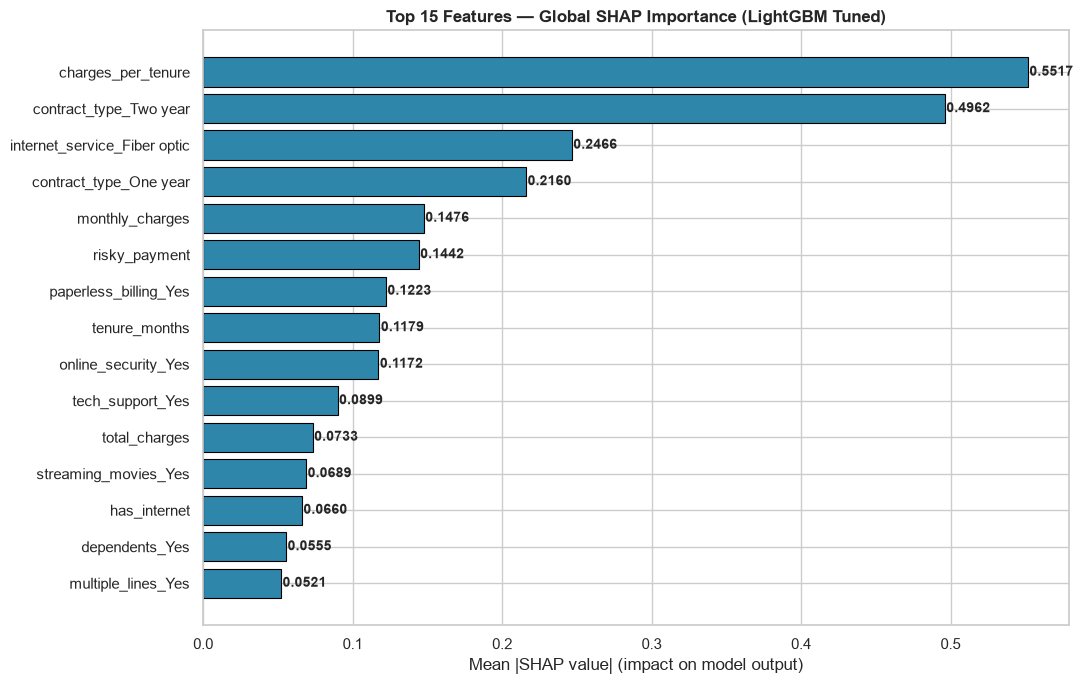

Saved → NTB07_shap_bar_importance.png


In [7]:
# Clean bar chart — top 15
top15 = shap_importance_df.head(15).iloc[::-1]  # reverse for horizontal bars

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15['feature'], top15['mean_abs_shap'],
               color='#2E86AB', edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, top15['mean_abs_shap']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Mean |SHAP value| (impact on model output)')
ax.set_title('Top 15 Features — Global SHAP Importance (LightGBM Tuned)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB07_shap_bar_importance.png")
plt.show()
print(f"Saved → NTB07_shap_bar_importance.png")

## 5. SHAP vs LR Coefficients — Cross-Model Consensus Check

If the feature rankings agree between a linear model (LR coefficients, NTB-03) and a non-linear ensemble (SHAP on LightGBM), we have **strong evidence** these features genuinely drive churn and aren't artifacts of one model's assumptions.

In [8]:
# Load LR coefficients from NTB-03
lr_coefs = pd.read_csv(REPORTS_DIR / "ntb03_lr_coefficients.csv")
lr_coefs = lr_coefs[['feature', 'abs_coef']].rename(columns={'abs_coef': 'lr_abs_coef'})
lr_coefs['lr_rank'] = lr_coefs['lr_abs_coef'].rank(ascending=False).astype(int)

# Merge with SHAP
shap_top = shap_importance_df.copy()
shap_top['shap_rank'] = shap_top['mean_abs_shap'].rank(ascending=False).astype(int)

consensus = shap_top.merge(lr_coefs, on='feature', how='inner')
consensus = consensus.sort_values('shap_rank').head(15)
consensus['rank_agreement'] = (consensus['shap_rank'] - consensus['lr_rank']).abs()

print("Top 15 by SHAP — cross-model rank comparison:")
print(consensus[['feature', 'shap_rank', 'lr_rank', 'rank_agreement', 'mean_abs_shap', 'lr_abs_coef']].to_string(index=False))
print(f"\nMean rank difference (top 15): {consensus['rank_agreement'].mean():.1f}")
print(f"(Lower = stronger agreement between SHAP and LR)")

Top 15 by SHAP — cross-model rank comparison:
                     feature  shap_rank  lr_rank  rank_agreement  mean_abs_shap  lr_abs_coef
          charges_per_tenure          1       13              12       0.551746     0.268044
      contract_type_Two year          2        1               1       0.496174     1.619546
internet_service_Fiber optic          3        2               1       0.246606     1.158591
      contract_type_One year          4        3               1       0.216042     0.742948
             monthly_charges          5        5               0       0.147605     0.497153
               risky_payment          6       37              31       0.144195     0.046371
       paperless_billing_Yes          7        8               1       0.122256     0.383416
               tenure_months          8        4               4       0.117871     0.675884
         online_security_Yes          9        7               2       0.117216     0.427460
            tech_support

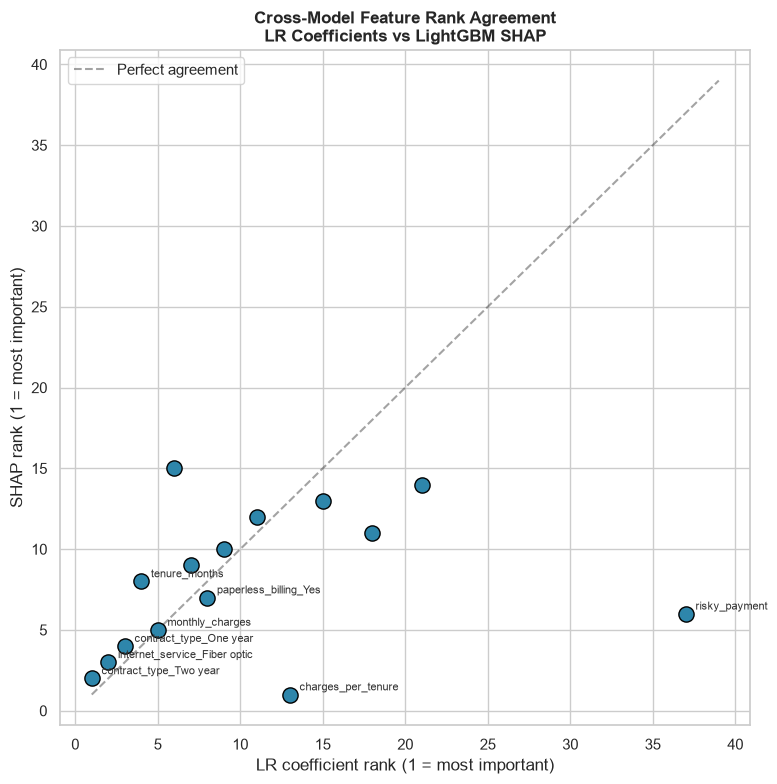

Saved → NTB07_shap_vs_lr_consensus.png


In [9]:
# Scatter plot: SHAP rank vs LR rank
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(consensus['lr_rank'], consensus['shap_rank'],
           s=120, color='#2E86AB', edgecolor='black', zorder=3)

# Label the top 8
for _, row in consensus.head(8).iterrows():
    ax.annotate(row['feature'], (row['lr_rank'], row['shap_rank']),
                textcoords='offset points', xytext=(7, 3),
                fontsize=8, color='#333333')

# Perfect agreement diagonal
max_rank = consensus[['shap_rank','lr_rank']].max().max() + 2
ax.plot([1, max_rank], [1, max_rank], 'k--', alpha=0.4, label='Perfect agreement')
ax.set_xlabel('LR coefficient rank (1 = most important)')
ax.set_ylabel('SHAP rank (1 = most important)')
ax.set_title('Cross-Model Feature Rank Agreement\nLR Coefficients vs LightGBM SHAP',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB07_shap_vs_lr_consensus.png")
plt.show()
print(f"Saved → NTB07_shap_vs_lr_consensus.png")

## 6. Dependence Plot — How Key Features Drive Churn

A dependence plot shows: as feature X changes in value, how does its SHAP contribution change? This reveals non-linear relationships that LR can't capture (another reason to use LightGBM).

Top 3 features: ['charges_per_tenure', 'contract_type_Two year', 'internet_service_Fiber optic']


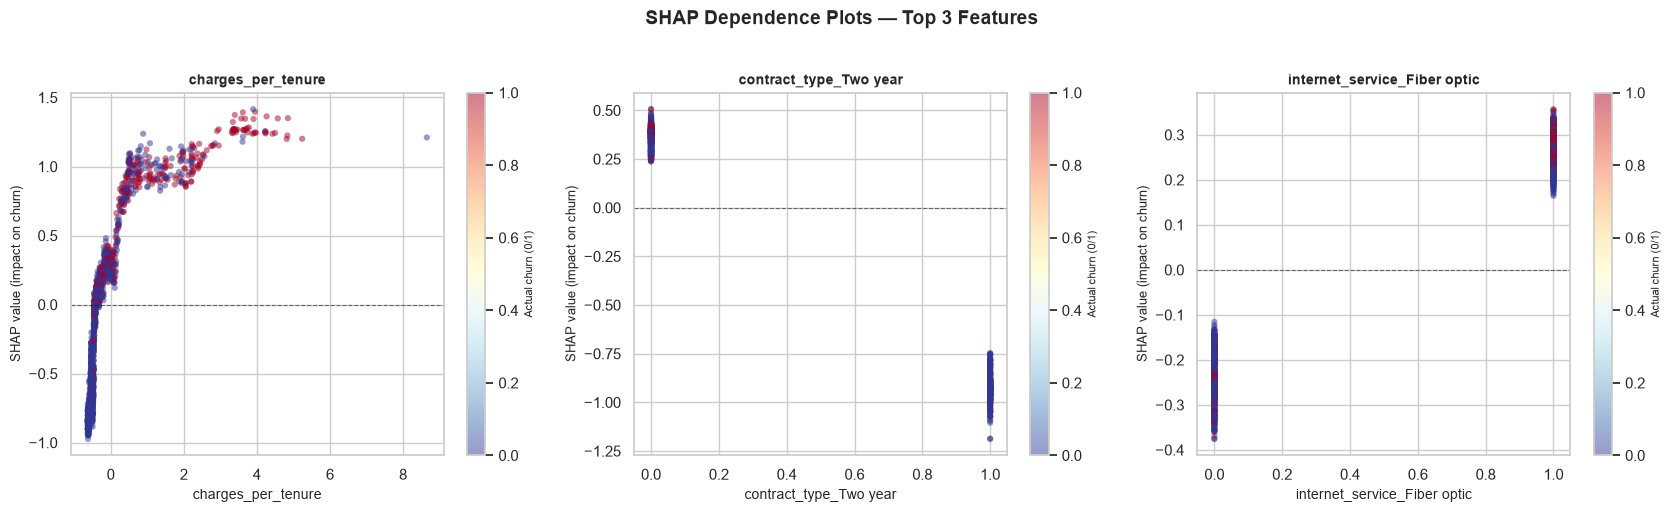

Saved → NTB07_shap_dependence_plots.png


In [10]:
# Get top 3 features by SHAP importance
top3_features = shap_importance_df.head(3)['feature'].tolist()
print(f"Top 3 features: {top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feat in zip(axes, top3_features):
    if feat not in feature_names:
        ax.text(0.5, 0.5, f"Feature '{feat}'\nnot found", ha='center')
        continue

    feat_idx = feature_names.index(feat)
    feat_shap = shap_values[:, feat_idx]
    feat_vals = X_test[feat].values

    # Color by churn label
    sc = ax.scatter(feat_vals, feat_shap,
                    c=y_test.values, cmap='RdYlBu_r',
                    alpha=0.5, s=20, edgecolors='none')

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP value (impact on churn)', fontsize=9)
    ax.set_title(feat, fontweight='bold', fontsize=10)

    # Colorbar for churn label
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Actual churn (0/1)', fontsize=8)

plt.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "NTB07_shap_dependence_plots.png")
plt.show()
print(f"Saved → NTB07_shap_dependence_plots.png")

## 7. The Waterfall Plot — Explaining One Customer's Prediction

This is the most powerful explainability visualization. It answers: **"Why is this specific customer predicted to churn?"**

We'll show three cases:
1. **A high-risk churner** (top predicted probability, and actually churned)
2. **A low-risk retained customer** (bottom predicted probability, actually retained)
3. **A false negative** (actually churned but model missed them)

This storytelling approach — showing what the model sees for real individual customers — is what separates a deployed ML system from a Jupyter notebook experiment.

In [11]:
# Get model predictions on test set
y_proba = champion.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Find example cases
test_results = pd.DataFrame({
    'idx': range(len(y_test)),
    'actual': y_test.values,
    'predicted_prob': y_proba,
    'predicted': y_pred
})

# Case 1: True positive — highest predicted probability among actual churners
tp_mask = (test_results['actual'] == 1) & (test_results['predicted'] == 1)
case1_idx = test_results.loc[tp_mask].nlargest(1, 'predicted_prob')['idx'].iloc[0]

# Case 2: True negative — lowest predicted probability among actual retaineds
tn_mask = (test_results['actual'] == 0) & (test_results['predicted'] == 0)
case2_idx = test_results.loc[tn_mask].nsmallest(1, 'predicted_prob')['idx'].iloc[0]

# Case 3: False negative — highest probability miss (churned but predicted retained)
fn_mask = (test_results['actual'] == 1) & (test_results['predicted'] == 0)
if fn_mask.any():
    case3_idx = test_results.loc[fn_mask].nlargest(1, 'predicted_prob')['idx'].iloc[0]
else:
    # fallback to any actual churner
    case3_idx = test_results.loc[test_results['actual'] == 1].iloc[0]['idx']

print(f"Case 1 (True positive  - high risk churner): idx={case1_idx}, prob={y_proba[case1_idx]:.4f}, actual={y_test.values[case1_idx]}")
print(f"Case 2 (True negative  - safe customer):     idx={case2_idx}, prob={y_proba[case2_idx]:.4f}, actual={y_test.values[case2_idx]}")
print(f"Case 3 (False negative - missed churner):    idx={case3_idx}, prob={y_proba[case3_idx]:.4f}, actual={y_test.values[case3_idx]}")

Case 1 (True positive  - high risk churner): idx=1109, prob=0.9447, actual=1
Case 2 (True negative  - safe customer):     idx=503, prob=0.0198, actual=0
Case 3 (False negative - missed churner):    idx=613, prob=0.4995, actual=1


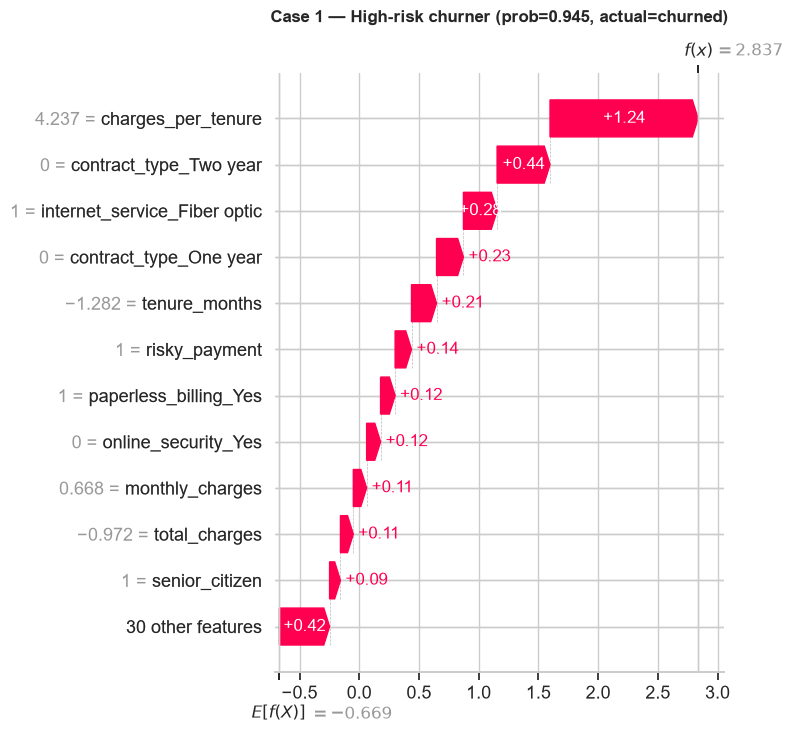

Saved → NTB07_waterfall_case_1.png


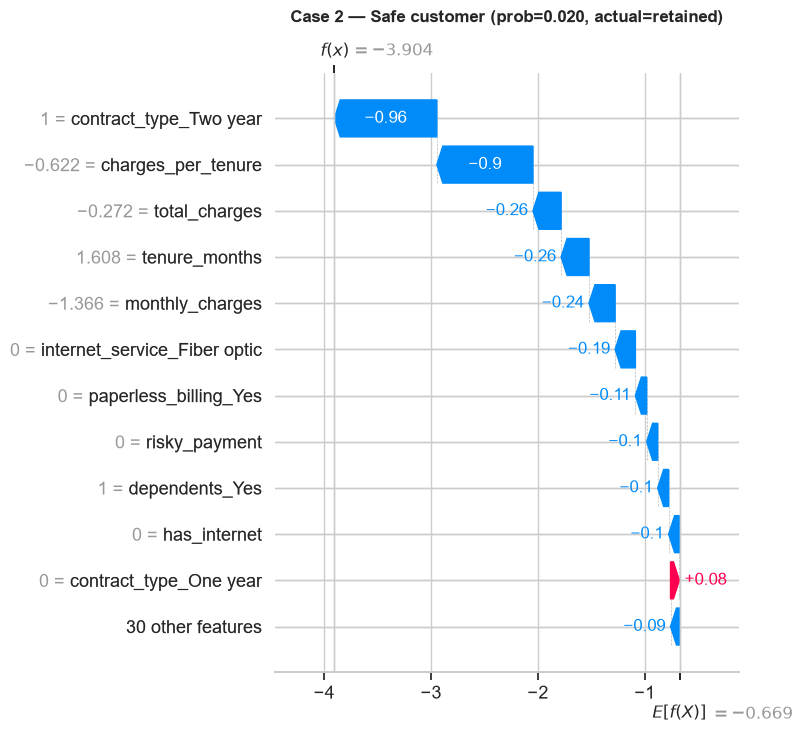

Saved → NTB07_waterfall_case_2.png


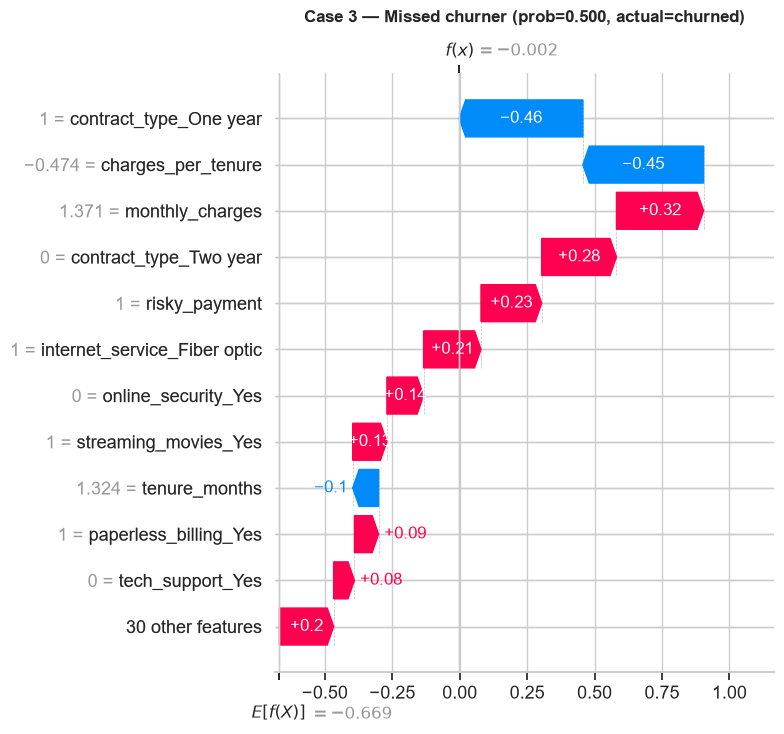

Saved → NTB07_waterfall_case_3.png


In [12]:
# Helper: build a SHAP Explanation for a single sample
def single_explanation(idx):
    return shap.Explanation(
        values=shap_values[idx],
        base_values=expected_value,
        data=X_test.iloc[idx].values,
        feature_names=feature_names
    )

case_labels = {
    case1_idx: f"Case 1 — High-risk churner (prob={y_proba[case1_idx]:.3f}, actual=churned)",
    case2_idx: f"Case 2 — Safe customer (prob={y_proba[case2_idx]:.3f}, actual=retained)",
    case3_idx: f"Case 3 — Missed churner (prob={y_proba[case3_idx]:.3f}, actual=churned)",
}

for idx, label in case_labels.items():
    fig, ax = plt.subplots(figsize=(11, 6))
    shap.plots.waterfall(single_explanation(idx), max_display=12, show=False)
    plt.title(label, fontweight='bold', pad=15)
    plt.tight_layout()
    safe_label = label.split("—")[0].strip().replace(" ", "_").lower()
    fname = f"NTB07_waterfall_{safe_label}.png"
    plt.savefig(FIG_DIR / fname)
    plt.show()
    print(f"Saved → {fname}")

**Reading the waterfall plot:**

- **E[f(x)]** (left) = base value — the model's average prediction before any customer-specific information
- **f(x)** (right) = this customer's final prediction
- **Red bars** push prediction UP (toward churn)
- **Blue bars** push prediction DOWN (away from churn)
- **Bar length** = magnitude of that feature's contribution for this specific customer

**Case 1 (high-risk churner):** You should see red bars for fiber optic, month-to-month contract, new customer, electronic check — exactly the risk factors we identified in NTB-01.

**Case 2 (safe customer):** You should see blue bars for two-year contract, long tenure, tech support subscription, auto-payment.

**Case 3 (missed churner):** This is the most interesting. Look at which features confused the model — were their risk factors hidden by other protective signals? This is how data scientists diagnose model blind spots.

## 8. Save SHAP Values for Downstream Use

In [13]:
# Save SHAP values as parquet — useful for NTB-08 (threshold optimization)
# and for any future analysis without recomputing
shap_df = pd.DataFrame(shap_values, columns=feature_names, index=X_test.index)
shap_df['expected_value'] = expected_value
shap_df['predicted_prob'] = y_proba
shap_df['actual_churn'] = y_test.values

shap_df.to_parquet(PROC_DIR / "shap_values_test.parquet", index=True)
print(f"SHAP values saved → data/processed/shap_values_test.parquet")
print(f"Shape: {shap_df.shape}")

# Quick summary for the README
print(f"\n--- For your README ---")
top5 = shap_importance_df.head(5)
for _, row in top5.iterrows():
    print(f"  {row['feature']:40s}  mean |SHAP| = {row['mean_abs_shap']:.4f}")

SHAP values saved → data/processed/shap_values_test.parquet
Shape: (1409, 44)

--- For your README ---
  charges_per_tenure                        mean |SHAP| = 0.5517
  contract_type_Two year                    mean |SHAP| = 0.4962
  internet_service_Fiber optic              mean |SHAP| = 0.2466
  contract_type_One year                    mean |SHAP| = 0.2160
  monthly_charges                           mean |SHAP| = 0.1476


## ✅ Deliverables From NTB-07

| Artifact | Path | For |
|---|---|---|
| Beeswarm plot | `reports/figures/NTB07_shap_beeswarm.png` | README, presentations |
| Bar importance | `reports/figures/NTB07_shap_bar_importance.png` | README, slides |
| Cross-model consensus | `reports/figures/NTB07_shap_vs_lr_consensus.png` | Technical story |
| Dependence plots (top 3) | `reports/figures/NTB07_shap_dependence_plots.png` | Deep dive |
| Waterfall — Case 1 | `reports/figures/NTB07_waterfall_case_1_*.png` | README feature, interviews |
| Waterfall — Case 2 | `reports/figures/NTB07_waterfall_case_2_*.png` | README feature |
| Waterfall — Case 3 | `reports/figures/NTB07_waterfall_case_3_*.png` | Model blind-spot story |
| SHAP importance CSV | `reports/ntb07_shap_importance.csv` | Leaderboard reference |
| SHAP values parquet | `data/processed/shap_values_test.parquet` | NTB-08, API responses |

## Next: NTB-08 — Cost-Sensitive Threshold Optimization

Right now every model is evaluated at threshold 0.5 — the default that minimizes errors symmetrically. But misclassification errors are NOT symmetric in churn:

- **False negative** (missed churner): lose the customer → ~$74/month forever
- **False positive** (wrong alarm): waste a retention offer → ~$20 one-time cost

The **optimal threshold is not 0.5**. In NTB-08 we'll:
1. Build a cost matrix from the NTB-01 business numbers
2. Sweep thresholds from 0.01 to 0.99
3. Find the threshold that **maximizes expected business value**
4. Show how much revenue the model can actually save at the optimal operating point

This is the notebook that makes the project financially defensible — and almost no junior portfolio has it.